In [1]:
# ==============================
# STEP 1: Import All Libraries
# ==============================

# Data handling
import pandas as pd
import numpy as np

# Visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive visualization (Dashboard)
import plotly.express as px
import plotly.io as pio

# Set plot styles
sns.set(style="whitegrid")
pio.renderers.default = "notebook"

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ==============================
# STEP 2: Define Paths
# ==============================

base_path = "C:/Users/Varnika Sharma/Desktop/Crime Analysis/Crime Analysis/01_Data/Cleaned_Dataset/"

ipc_path = base_path + "IPC_CRIMES/"
women_path = base_path + "WOMEN_CRIMES/"
children_path = base_path + "CHILDREN_CRIMES/"
cyber_path = base_path + "CYBER_CRIMES/"

print("Paths set successfully!")

Paths set successfully!


In [3]:
# ==============================
# STEP 3: Universal Processing Function
# ==============================

def process_dataset(file_path, year, dataset_name):
    df = pd.read_excel(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Handle State column variations
    if "State/UT" in df.columns:
        df.rename(columns={"State/UT": "State"}, inplace=True)
    elif "STATE/UT" in df.columns:
        df.rename(columns={"STATE/UT": "State"}, inplace=True)
    elif "State" not in df.columns:
        df.rename(columns={df.columns[1]: "State"}, inplace=True)

    # Drop serial column if exists
    if "SL" in df.columns:
        df.drop(columns=["SL"], inplace=True)

    # Convert wide → long
    df_long = pd.melt(
        df,
        id_vars=["State"],
        var_name="Crime_Info",
        value_name="Value"
    )

    # Split Crime_Info into parts
    df_long[["Category", "Crime", "Metric"]] = df_long["Crime_Info"].str.rsplit("_", n=2, expand=True)

    # Clean values
    df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
    df_long.dropna(inplace=True)

    # Remove totals (very important)
    df_long = df_long[~df_long["Crime"].str.contains("total|all", case=False, na=False)]

    # Add metadata
    df_long["Year"] = year
    df_long["Dataset"] = dataset_name

    print(f"{dataset_name} {year} processed successfully. Shape:", df_long.shape)

    return df_long

In [4]:
# ==============================
# STEP 4: Load Datasets (2021)
# ==============================

ipc_2021 = process_dataset(ipc_path + "IPC_Crimes_Head-wise_Raw_2021.xlsx", 2021, "IPC")
women_2021 = process_dataset(women_path + "Crimes_Against_Women_Head-wise_State-UT_Raw_2021.xlsx", 2021, "Women")
children_2021 = process_dataset(children_path + "Crimes_Against_Children_State-UT_2021.xlsx", 2021, "Children")
cyber_2021 = process_dataset(cyber_path + "Cyber_Crimes_State-UT_2021.xlsx", 2021, "Cyber")

IPC 2021 processed successfully. Shape: (12816, 8)
Women 2021 processed successfully. Shape: (4572, 8)
Children 2021 processed successfully. Shape: (5976, 8)
Cyber 2021 processed successfully. Shape: (1548, 8)


In [5]:
# ==============================
# STEP 5: Combine Datasets
# ==============================

final_df = pd.concat(
    [ipc_2021, women_2021, children_2021, cyber_2021],
    ignore_index=True
)

print("Final dataset shape:", final_df.shape)
display(final_df.head())

Final dataset shape: (24912, 8)


,State,Crime_Info,Value,Category,Crime,Metric,Year,Dataset
0,Andhra Pradesh,Offences affecting the Human Body_Murder (Sec....,956.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
1,Arunachal Pradesh,Offences affecting the Human Body_Murder (Sec....,49.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
2,Assam,Offences affecting the Human Body_Murder (Sec....,1192.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
3,Bihar,Offences affecting the Human Body_Murder (Sec....,2799.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
4,Chhattisgarh,Offences affecting the Human Body_Murder (Sec....,1007.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC


In [6]:
print(final_df["Dataset"].value_counts())
print(final_df["Year"].value_counts())

Dataset
IPC         12816
Children     5976
Women        4572
Cyber        1548
Name: count, dtype: int64
Year
2021    24912
Name: count, dtype: int64


In [7]:
# ==============================
# STEP 6: Load Datasets (All Years)
# ==============================

# ---- 2021 ----
ipc_2021 = process_dataset(ipc_path + "IPC_Crimes_Head-wise_Raw_2021.xlsx", 2021, "IPC")
women_2021 = process_dataset(women_path + "Crimes_Against_Women_Head-wise_State-UT_Raw_2021.xlsx", 2021, "Women")
children_2021 = process_dataset(children_path + "Crimes_Against_Children_State-UT_2021.xlsx", 2021, "Children")
cyber_2021 = process_dataset(cyber_path + "Cyber_Crimes_State-UT_2021.xlsx", 2021, "Cyber")

# ---- 2022 ----
ipc_2022 = process_dataset(ipc_path + "IPC_Crimes_Head-wise_Raw_2022.xlsx", 2022, "IPC")
women_2022 = process_dataset(women_path + "Crimes_Against_Women_Head-wise_State-UT_Raw_2021.xlsx", 2022, "Women")
children_2022 = process_dataset(children_path + "Crimes_Against_Children_State-UT_2021.xlsx", 2022, "Children")
cyber_2022 = process_dataset(cyber_path + "Cyber_Crimes_State-UT_2021.xlsx", 2022, "Cyber")

# ---- 2023 ----
ipc_2023 = process_dataset(ipc_path + "IPC_Crimes_Head-wise_Raw_2023.xlsx", 2023, "IPC")
women_2023 = process_dataset(women_path + "Crimes_Against_Women_Head-wise_State-UT_Raw_2021.xlsx", 2023, "Women")
children_2023 = process_dataset(children_path + "Crimes_Against_Children_State-UT_2021.xlsx", 2023, "Children")
cyber_2023 = process_dataset(cyber_path + "Cyber_Crimes_State-UT_2021.xlsx", 2023, "Cyber")

IPC 2021 processed successfully. Shape: (12816, 8)
Women 2021 processed successfully. Shape: (4572, 8)
Children 2021 processed successfully. Shape: (5976, 8)
Cyber 2021 processed successfully. Shape: (1548, 8)
IPC 2022 processed successfully. Shape: (12816, 8)
Women 2022 processed successfully. Shape: (4572, 8)
Children 2022 processed successfully. Shape: (5976, 8)
Cyber 2022 processed successfully. Shape: (1548, 8)
IPC 2023 processed successfully. Shape: (12816, 8)
Women 2023 processed successfully. Shape: (4572, 8)
Children 2023 processed successfully. Shape: (5976, 8)
Cyber 2023 processed successfully. Shape: (1548, 8)


In [8]:
# ==============================
# STEP 7: Combine All Years
# ==============================

final_df = pd.concat([
    ipc_2021, women_2021, children_2021, cyber_2021,
    ipc_2022, women_2022, children_2022, cyber_2022,
    ipc_2023, women_2023, children_2023, cyber_2023
], ignore_index=True)

print("Final dataset shape:", final_df.shape)
display(final_df.head())

Final dataset shape: (74736, 8)


,State,Crime_Info,Value,Category,Crime,Metric,Year,Dataset
0,Andhra Pradesh,Offences affecting the Human Body_Murder (Sec....,956.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
1,Arunachal Pradesh,Offences affecting the Human Body_Murder (Sec....,49.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
2,Assam,Offences affecting the Human Body_Murder (Sec....,1192.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
3,Bihar,Offences affecting the Human Body_Murder (Sec....,2799.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
4,Chhattisgarh,Offences affecting the Human Body_Murder (Sec....,1007.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC


In [9]:
print(final_df["Year"].value_counts())
print(final_df["Dataset"].value_counts())

Year
2021    24912
2022    24912
2023    24912
Name: count, dtype: int64
Dataset
IPC         38448
Children    17928
Women       13716
Cyber        4644
Name: count, dtype: int64


In [10]:
# ==============================
# STEP 8: Data Validation
# ==============================

print("Shape:", final_df.shape)

print("\nColumns:")
print(final_df.columns)

print("\nNull values:")
print(final_df.isnull().sum())

print("\nUnique Years:")
print(final_df["Year"].unique())

print("\nDatasets:")
print(final_df["Dataset"].unique())

Shape: (74736, 8)

Columns:
Index(['State', 'Crime_Info', 'Value', 'Category', 'Crime', 'Metric', 'Year',
       'Dataset'],
      dtype='str')

Null values:
State         0
Crime_Info    0
Value         0
Category      0
Crime         0
Metric        0
Year          0
Dataset       0
dtype: int64

Unique Years:
[2021 2022 2023]

Datasets:
<StringArray>
['IPC', 'Women', 'Children', 'Cyber']
Length: 4, dtype: str


In [11]:
# ==============================
# STEP 9: Final Cleaning
# ==============================

# Keep only actual cases
df_clean = final_df[final_df["Metric"] == "I"].copy()

# Remove unwanted aggregated entries
df_clean = df_clean[~df_clean["Crime"].str.contains("total|all", case=False, na=False)]

# Convert to numeric again (safe)
df_clean["Value"] = pd.to_numeric(df_clean["Value"], errors="coerce")

df_clean.dropna(inplace=True)

print("Cleaned shape:", df_clean.shape)
display(df_clean.head())

Cleaned shape: (23112, 8)


,State,Crime_Info,Value,Category,Crime,Metric,Year,Dataset
0,Andhra Pradesh,Offences affecting the Human Body_Murder (Sec....,956.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
1,Arunachal Pradesh,Offences affecting the Human Body_Murder (Sec....,49.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
2,Assam,Offences affecting the Human Body_Murder (Sec....,1192.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
3,Bihar,Offences affecting the Human Body_Murder (Sec....,2799.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC
4,Chhattisgarh,Offences affecting the Human Body_Murder (Sec....,1007.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC


In [12]:
# =================================
# STEP-10: Exploratory Data Analysis
# =================================
#Year-wise Trends
year_trend = df_clean.groupby("Year")["Value"].sum().reset_index()
display(year_trend)

,Year,Value
0,2021,4878883.0
1,2022,4808262.0
2,2023,5050162.0


In [13]:
#Dataset-wise Distribution
dataset_dist = df_clean.groupby("Dataset")["Value"].sum().reset_index()
display(dataset_dist)

,Dataset,Value
0,Children,659502.0
1,IPC,12793277.0
2,Women,1284528.0


In [14]:
#Top States
top_states = (
    df_clean.groupby("State")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_states)

State
Uttar Pradesh     1665085.0
Maharashtra       1501213.0
Madhya Pradesh    1387883.0
Delhi             1026039.0
Bihar             1013383.0
Rajasthan          925706.0
Tamil Nadu         883166.0
Kerala             724742.0
West Bengal        692042.0
Gujarat            636315.0
Name: Value, dtype: float64


In [15]:
#Top Crimes
top_crimes = (
    df_clean.groupby("Crime")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_crimes)

Crime
                                                                           11408573.0
A) Voluntarily Causing Simple Hurt (Sec.323 r/w 341/342)                     926038.0
B) Voluntarily causing hurt by Dangerous weapons or means (Sec.324 IPC)      531917.0
B) Other Accidents (other than Hit and Run)                                  303174.0
A) Voluntarily causing grievous hurt (Sec.325 IPC)                           221565.0
Kidnapping and Abduction (Sec.363 IPC)                                       186904.0
A) Girls                                                                     158508.0
A) Hit and Run                                                               143085.0
Fraud (Sec.420 r/w Sec.465,468-471 IPC/IT Act)                               106459.0
A) Missing Children Deemed as Kidnapped                                       99653.0
Name: Value, dtype: float64


In [16]:
# ==============================
# STEP-11: Statistical Analysis
# ==============================
print(df_clean["Value"].describe())

count     23112.000000
mean        637.647413
std        4463.002442
min           0.000000
25%           0.000000
50%           3.000000
75%          55.000000
max      188492.000000
Name: Value, dtype: float64


In [17]:
variance_analysis = (
    df_clean.groupby("Crime")["Value"]
    .var()
    .sort_values(ascending=False)
    .head(10)
)

print(variance_analysis)

Crime
A) Voluntarily Causing Simple Hurt (Sec.323 r/w 341/342)                   3.186809e+08
B) Voluntarily causing hurt by Dangerous weapons or means (Sec.324 IPC)    7.804914e+07
                                                                           2.166176e+07
A) Voluntarily causing grievous hurt (Sec.325 IPC)                         1.678450e+07
B) Other Accidents (other than Hit and Run)                                1.283099e+07
A) Hit and Run                                                             8.845671e+06
Kidnapping and Abduction (Sec.363 IPC)                                     7.714733e+06
Fraud (Sec.420 r/w Sec.465,468-471 IPC/IT Act)                             4.050022e+06
A) Missing Children Deemed as Kidnapped                                    2.924739e+06
d) Other Frauds                                                            2.577816e+06
Name: Value, dtype: float64


In [18]:
std_analysis = (
    df_clean.groupby("Crime")["Value"]
    .std()
    .sort_values(ascending=False)
    .head(10)
)

print(std_analysis)

Crime
A) Voluntarily Causing Simple Hurt (Sec.323 r/w 341/342)                   17851.637178
B) Voluntarily causing hurt by Dangerous weapons or means (Sec.324 IPC)     8834.542192
                                                                            4654.219841
A) Voluntarily causing grievous hurt (Sec.325 IPC)                          4096.888891
B) Other Accidents (other than Hit and Run)                                 3582.036622
A) Hit and Run                                                              2974.167231
Kidnapping and Abduction (Sec.363 IPC)                                      2777.540810
Fraud (Sec.420 r/w Sec.465,468-471 IPC/IT Act)                              2012.466588
A) Missing Children Deemed as Kidnapped                                     1710.186747
d) Other Frauds                                                             1605.557918
Name: Value, dtype: float64


In [19]:
pivot_df = df_clean.pivot_table(
    index="State",
    columns="Dataset",
    values="Value",
    aggfunc="sum"
).fillna(0)

correlation = pivot_df.corr()

print(correlation)

Dataset   Children       IPC     Women
Dataset                               
Children  1.000000  0.901893  0.879664
IPC       0.901893  1.000000  0.828575
Women     0.879664  0.828575  1.000000


In [20]:
# ==============================
#  Step-12: Advanced Feature Engineering
# ==============================

df_feat = df_clean.copy()

# 1. Total crimes per state-year
df_feat["State_Total"] = df_feat.groupby(["State", "Year"])["Value"].transform("sum")

# 2. Crime share
df_feat["Crime_Share"] = df_feat["Value"] / df_feat["State_Total"]

# 3. Dataset total
df_feat["Dataset_Total"] = df_feat.groupby(["Dataset", "Year"])["Value"].transform("sum")

# 4. Contribution %
df_feat["Contribution_%"] = (df_feat["Value"] / df_feat["Dataset_Total"]) * 100

# 5. Previous year value
df_feat["Prev_Value"] = df_feat.groupby(["State", "Crime"])["Value"].shift(1)

# 6. Growth rate
df_feat["Growth_Rate"] = ((df_feat["Value"] - df_feat["Prev_Value"]) / df_feat["Prev_Value"]) * 100

# Fill NaN for first year
df_feat["Growth_Rate"] = df_feat["Growth_Rate"].fillna(0)

# 7. Rank of crimes within state
df_feat["Crime_Rank_State"] = df_feat.groupby(["State", "Year"])["Value"].rank(ascending=False)

# 8. Rank of states (overall)
df_feat["State_Rank"] = df_feat.groupby("Year")["Value"].rank(ascending=False)

# 9. High crime flag
df_feat["High_Crime_Flag"] = df_feat["Value"] > df_feat["Value"].mean()

# 10. Intensity bucket
try:
    df_feat["Intensity"] = pd.qcut(df_feat["Value"], q=4, labels=["Low", "Medium", "High", "Very High"], duplicates="drop")
except:
    df_feat["Intensity"] = pd.cut(df_feat["Value"], bins=3, labels=["Low", "Medium", "High"])
# 11. Log transformation
df_feat["Log_Value"] = np.log1p(df_feat["Value"])

# 12. Z-score (statistical normalization)
df_feat["Z_Score"] = (df_feat["Value"] - df_feat["Value"].mean()) / df_feat["Value"].std()

# 13. Yearly change absolute
df_feat["Yearly_Change"] = df_feat["Value"] - df_feat["Prev_Value"]
df_feat["Yearly_Change"] = df_feat["Yearly_Change"].fillna(0)

# 14. Dataset share within state
df_feat["Dataset_State_Share"] = df_feat["Value"] / df_feat.groupby(["State","Year"])["Value"].transform("sum")

# 15. Crime frequency category
df_feat["Frequency"] = pd.cut(
    df_feat["Value"],
    bins=3,
    labels=["Rare", "Moderate", "Frequent"]
)

print("Total columns:", len(df_feat.columns))
display(df_feat.head())

Total columns: 23


,State,Crime_Info,Value,Category,Crime,Metric,Year,Dataset,State_Total,Crime_Share,...,Growth_Rate,Crime_Rank_State,State_Rank,High_Crime_Flag,Intensity,Log_Value,Z_Score,Yearly_Change,Dataset_State_Share,Frequency
0,Andhra Pradesh,Offences affecting the Human Body_Murder (Sec....,956.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC,219346.0,0.004358,...,0.0,30.0,660.5,True,Low,6.863803,0.071331,0.0,0.004358,Rare
1,Arunachal Pradesh,Offences affecting the Human Body_Murder (Sec....,49.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC,3468.0,0.014129,...,0.0,21.0,1992.5,False,Low,3.912023,-0.131895,0.0,0.014129,Rare
2,Assam,Offences affecting the Human Body_Murder (Sec....,1192.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC,174156.0,0.006844,...,0.0,34.0,574.0,True,Low,7.084226,0.124211,0.0,0.006844,Rare
3,Bihar,Offences affecting the Human Body_Murder (Sec....,2799.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC,301723.0,0.009277,...,0.0,17.0,324.0,True,Low,7.937375,0.484282,0.0,0.009277,Rare
4,Chhattisgarh,Offences affecting the Human Body_Murder (Sec....,1007.0,Offences affecting the Human Body_Murder (Sec....,,I,2021,IPC,112659.0,0.008938,...,0.0,26.0,635.5,True,Low,6.915723,0.082759,0.0,0.008938,Rare


In [21]:
print("Skewness:", df_clean["Value"].skew())

Skewness: 19.845518623617533


In [22]:
print("Kurtosis:", df_clean["Value"].kurt())

Kurtosis: 559.214085053284


In [23]:
crime_stats = df_clean.groupby("Crime")["Value"].agg([
    "mean", "median", "std", "var", "skew"
]).sort_values(by="mean", ascending=False).head(10)

print(crime_stats)

                                                           mean  median  \
Crime                                                                     
A) Voluntarily Causing Simple Hurt (Sec.323 r/w...  8574.425926  1191.5   
B) Voluntarily causing hurt by Dangerous weapon...  4925.157407   409.0   
B) Other Accidents (other than Hit and Run)         2807.166667   935.5   
A) Voluntarily causing grievous hurt (Sec.325 I...  2051.527778   313.5   
Kidnapping and Abduction (Sec.363 IPC)              1730.592593   280.0   
A) Hit and Run                                      1324.861111   230.5   
Fraud (Sec.420 r/w Sec.465,468-471 IPC/IT Act)       985.731481   213.0   
A) Missing Children Deemed as Kidnapped              922.712963    65.5   
B) Other Kidnapping & Abduction                      807.879630   188.5   
A) Missing Children Deemed as\nKidnapped             798.777778    66.5   

                                                             std  \
Crime                          

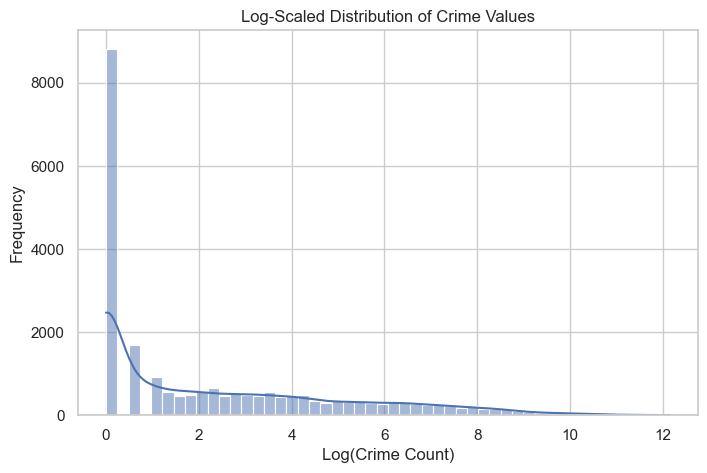

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df_clean["Value"]), bins=50, kde=True)

plt.title("Log-Scaled Distribution of Crime Values")
plt.xlabel("Log(Crime Count)")
plt.ylabel("Frequency")

#Save
plt.savefig("C:/Users/Varnika Sharma/Desktop/Crime Analysis/Crime Analysis/04_Visuals/log_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

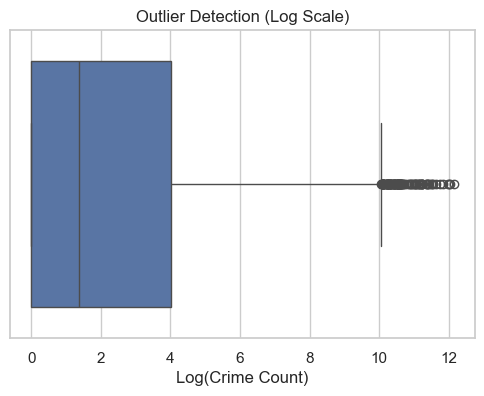

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=np.log1p(df_clean["Value"]))

plt.title("Outlier Detection (Log Scale)")
plt.xlabel("Log(Crime Count)")
#Save
plt.savefig("C:/Users/Varnika Sharma/Desktop/Crime Analysis/Crime Analysis/04_Visuals/outliers_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

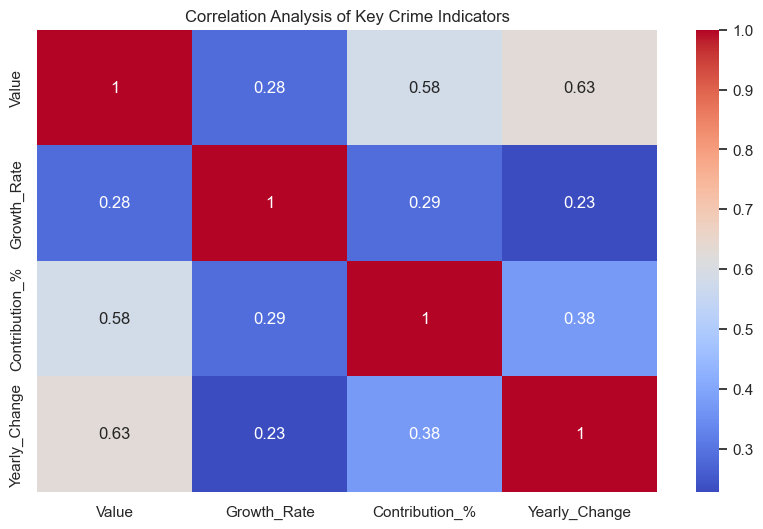

In [35]:
#Correlation Heatmap
cols = [
    "Value",
    "Growth_Rate",
    "Contribution_%",
    "Yearly_Change"
]

plt.figure(figsize=(10,6))

sns.heatmap(df_feat[cols].corr(), cmap='coolwarm', annot=True)

plt.title("Correlation Analysis of Key Crime Indicators")
plt.savefig("C:/Users/Varnika Sharma/Desktop/Crime Analysis/Crime Analysis/04_Visuals/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()